<a href="https://colab.research.google.com/github/AnnaMilagres/estudo-dirigido-1/blob/main/estudo_dirigido_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simulações

## Importando bibliotecas

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Tópico 1 - Sinais Contínuos e Discretos

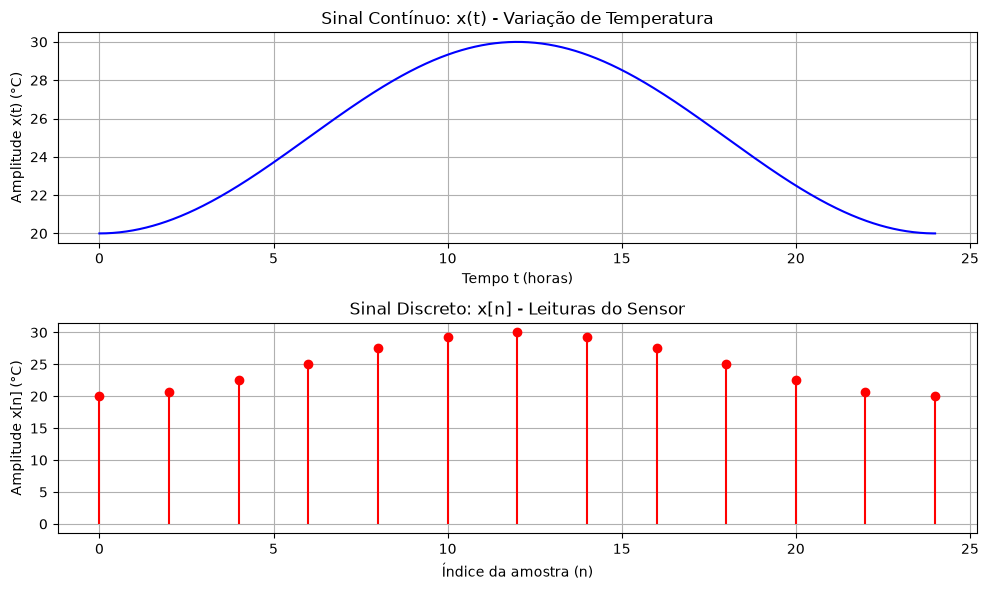

In [ ]:
# parâmetros do sinal
frequencia = 1 / 24.0
amplitude = 5 # variação de +- 5 graus
offset = 25 # temperatura média
fase = np.pi # Ajuste de fase para o vale ser de madrugada

# geração do sinal "contínuo"
t_continuo = np.linspace(0, 24, 1000)
x_continuo = offset + amplitude * np.cos(2 * np.pi * frequencia * t_continuo + fase)

# geração do sinal discreto
n_discreto = np.arange(0, 25, 2)
x_discreto = offset + amplitude * np.cos(2 * np.pi * frequencia * n_discreto + fase)


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))

# gráfico contínuo
ax1.plot(t_continuo, x_continuo, color='blue')
ax1.set_title('Sinal Contínuo: x(t) - Variação de Temperatura')
ax1.set_xlabel('Tempo t (horas)')
ax1.set_ylabel('Amplitude x(t) (°C)')
ax1.grid(True)

# gráfico discreto
ax2.stem(n_discreto, x_discreto, basefmt=" ", linefmt='red', markerfmt='ro')
ax2.set_title('Sinal Discreto: x[n] - Leituras do Sensor')
ax2.set_xlabel('Índice da amostra (n)')
ax2.set_ylabel('Amplitude x[n] (°C)')
ax2.grid(True)

plt.tight_layout()
plt.show()

## Tópico 2 - Amostragem

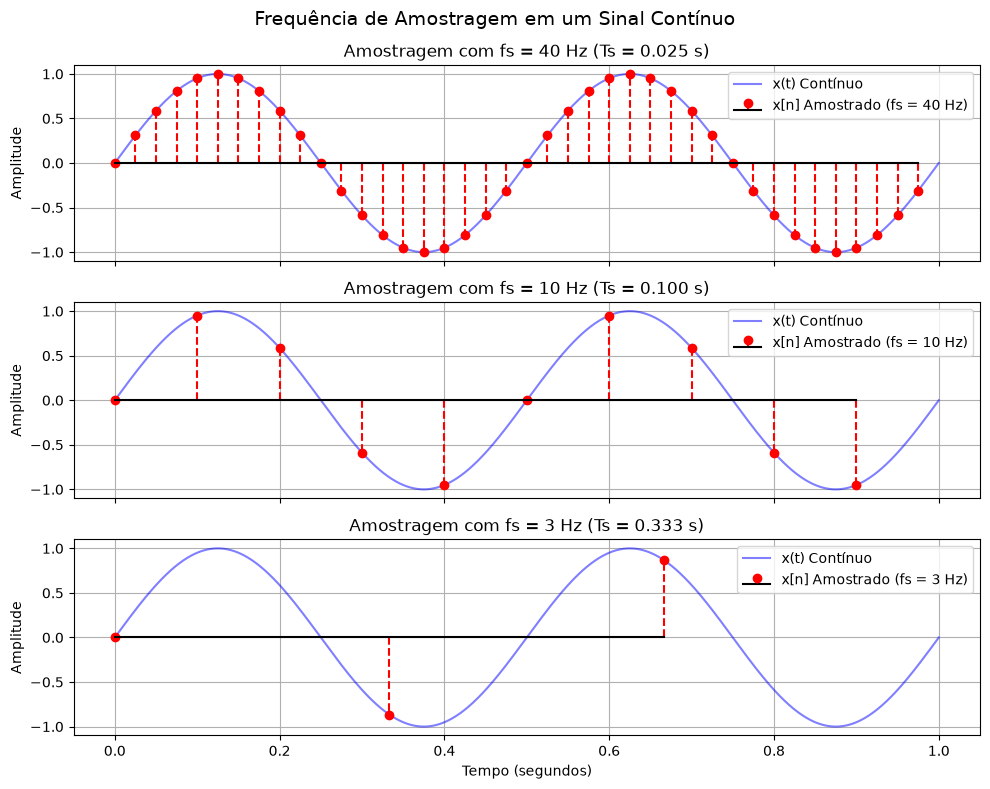

In [3]:
# parâmetros do sinal
f0 = 2
t_continuo = np.linspace(0, 1, 1000)
x_continuo = np.sin(2 * np.pi * f0 * t_continuo)

# frequências de amostragem diferentes
fs_valores = [40, 10, 3] # Hz

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
fig.suptitle('Frequência de Amostragem em um Sinal Contínuo', fontsize=14)

for i, fs in enumerate(fs_valores):
    Ts = 1 / fs
    # nTs define os instantes de aquisição
    t_amostras = np.arange(0, 1, Ts)
    x_amostrado = np.sin(2 * np.pi * f0 * t_amostras)

    # plotagem do sinal contínuo e amostras
    axes[i].plot(t_continuo, x_continuo, 'b-', alpha=0.5, label='x(t) Contínuo')
    axes[i].stem(t_amostras, x_amostrado, linefmt='r--', markerfmt='ro', basefmt='k-', label=f'x[n] Amostrado (fs = {fs} Hz)')
    axes[i].set_title(f'Amostragem com fs = {fs} Hz (Ts = {Ts:.3f} s)')
    axes[i].set_ylabel('Amplitude')
    axes[i].grid(True)
    axes[i].legend(loc='upper right')

axes[-1].set_xlabel('Tempo (segundos)')
plt.tight_layout()
plt.show()

## Tópico 3 - Quantização e Resolução

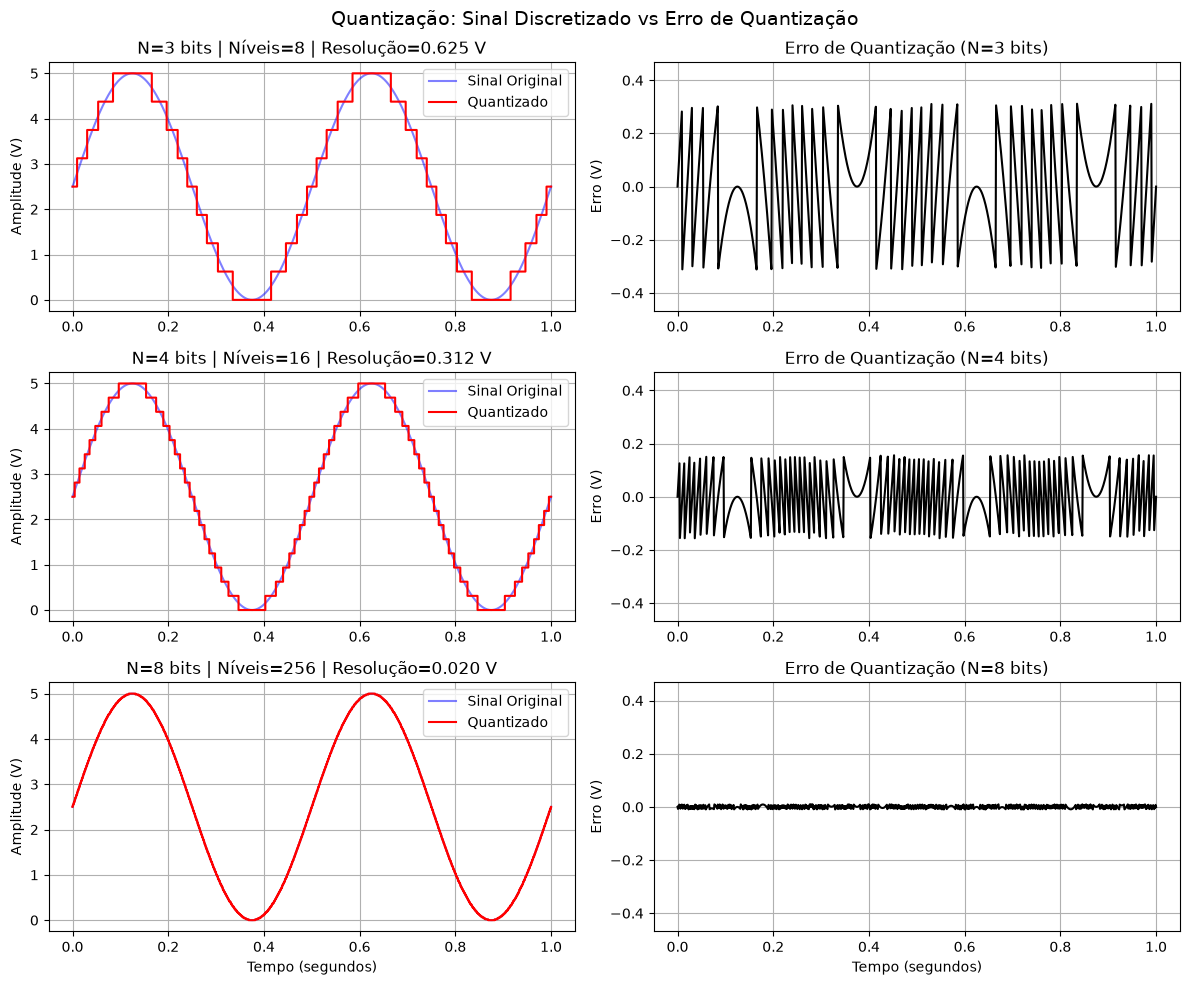

In [4]:
# parâmetros do sinal
t = np.linspace(0, 1, 1000)
Vref = 5.0
x_original = (Vref / 2) * np.sin(2 * np.pi * 2 * t) + (Vref / 2)

bits_list = [3, 4, 8]

fig, axes = plt.subplots(3, 2, figsize=(12, 10))
fig.suptitle('Quantização: Sinal Discretizado vs Erro de Quantização', fontsize=14)

for i, N in enumerate(bits_list):
    L = 2**N
    Delta_V = Vref / L

    # processo de quantização
    x_quantizado = np.round(x_original / Delta_V) * Delta_V
    x_quantizado = np.clip(x_quantizado, 0, Vref)

    # cálculo do erro de quantização
    erro = x_original - x_quantizado

    # plot do sinal quantizado
    axes[i, 0].plot(t, x_original, 'b-', alpha=0.5, label='Sinal Original')
    axes[i, 0].step(t, x_quantizado, 'r-', where='mid', label=f'Quantizado')
    axes[i, 0].set_title(f'N={N} bits | Níveis={L} | Resolução={Delta_V:.3f} V')
    axes[i, 0].set_ylabel('Amplitude (V)')
    axes[i, 0].grid(True)
    axes[i, 0].legend(loc='upper right')

    # plot do erro de quantização
    axes[i, 1].plot(t, erro, 'k-')
    axes[i, 1].set_title(f'Erro de Quantização (N={N} bits)')
    axes[i, 1].set_ylabel('Erro (V)')
    axes[i, 1].grid(True)
    limit = (Vref / (2**3)) / 2
    axes[i, 1].set_ylim(-limit * 1.5, limit * 1.5)

axes[2, 0].set_xlabel('Tempo (segundos)')
axes[2, 1].set_xlabel('Tempo (segundos)')
plt.tight_layout()
plt.show()

## Tópico 4 - Sequências fundamentais

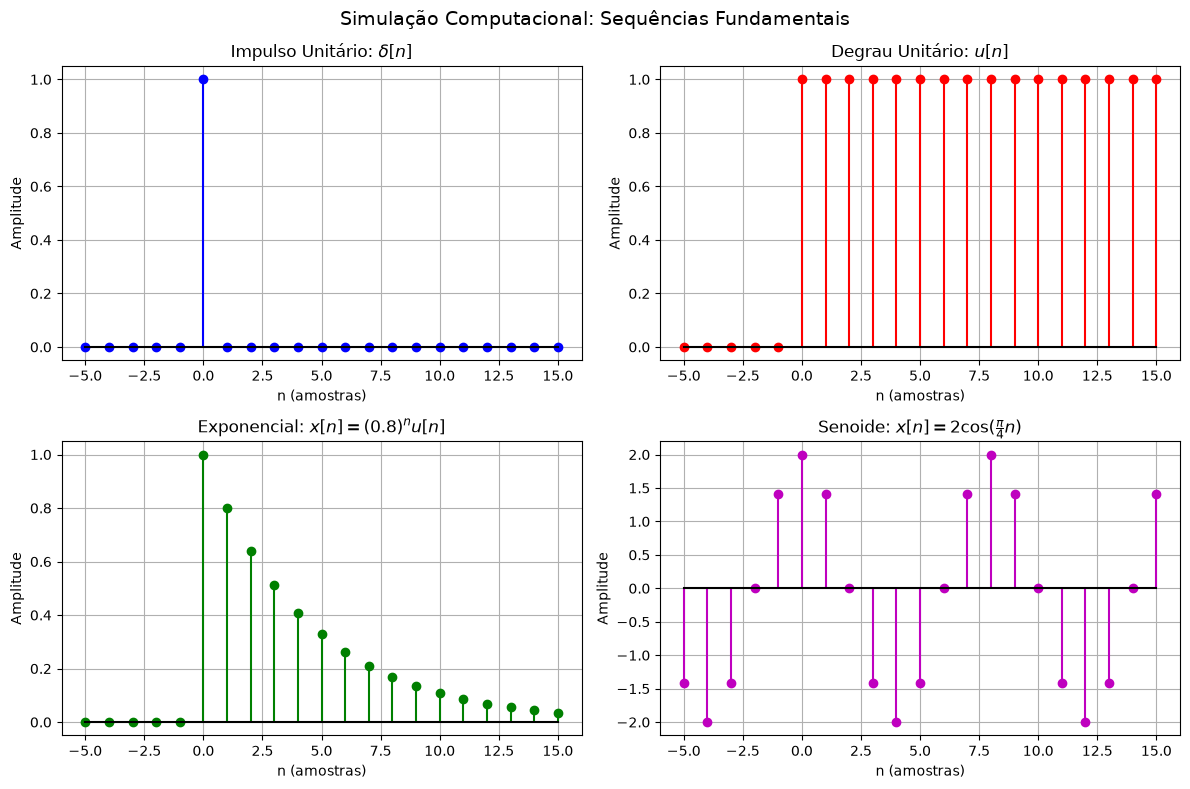

In [5]:
# definição do vetor
n = np.arange(-5, 16)

# impulso unitário
impulso = np.where(n == 0, 1, 0)

# degrau unitário
degrau = np.where(n >= 0, 1, 0)

# exponencial
a = 0.8
exponencial = (a**n) * degrau

# senoide discreta
A = 2
w0 = np.pi / 4
phi = 0
senoide = A * np.cos(w0 * n + phi)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Simulação Computacional: Sequências Fundamentais', fontsize=14)

# impulso
axes[0, 0].stem(n, impulso, linefmt='b-', markerfmt='bo', basefmt='k-')
axes[0, 0].set_title(r'Impulso Unitário: $\delta[n]$')
axes[0, 0].grid(True)

# degrau
axes[0, 1].stem(n, degrau, linefmt='r-', markerfmt='ro', basefmt='k-')
axes[0, 1].set_title(r'Degrau Unitário: $u[n]$')
axes[0, 1].grid(True)

# exponencial
axes[1, 0].stem(n, exponencial, linefmt='g-', markerfmt='go', basefmt='k-')
axes[1, 0].set_title(r'Exponencial: $x[n] = (0.8)^n u[n]$')
axes[1, 0].grid(True)

# senoide
axes[1, 1].stem(n, senoide, linefmt='m-', markerfmt='mo', basefmt='k-')
axes[1, 1].set_title(r'Senoide: $x[n] = 2\cos(\frac{\pi}{4}n)$')
axes[1, 1].grid(True)

for ax in axes.flat:
    ax.set_xlabel('n (amostras)')
    ax.set_ylabel('Amplitude')

plt.tight_layout()
plt.show()

## Tópico 5 - Operações com Sinais

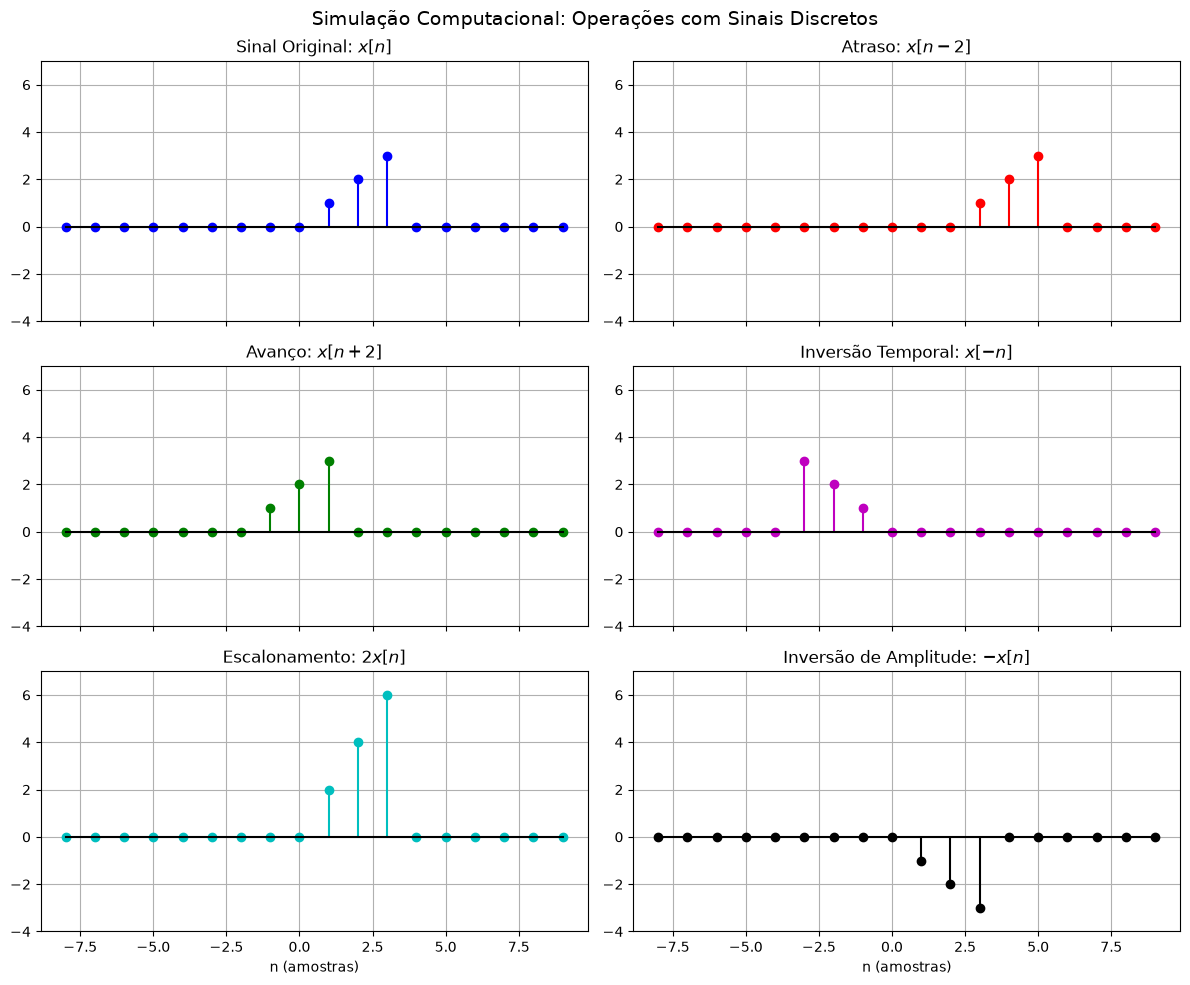

In [7]:
# definição do vetor
n = np.arange(-8, 10)

# função para gerar o sinal original
def sinal_x(n_vetor):
    return np.where((n_vetor >= 0) & (n_vetor <= 3), n_vetor, 0)

# sinal original
x_original = sinal_x(n)

# deslocamentos
x_atrasado = sinal_x(n - 2)  # x[n-2]
x_avancado = sinal_x(n + 2)  # x[n+2]

# inversão temporal
x_invertido_tempo = sinal_x(-n) # x[-n]

# operações de amplitude
x_amplificado = 2 * sinal_x(n)  # 2x[n]
x_invertido_amp = -sinal_x(n)   # -x[n]

fig, axes = plt.subplots(3, 2, figsize=(12, 10), sharex=True)
fig.suptitle('Simulação Computacional: Operações com Sinais Discretos', fontsize=14)

operacoes = [
    (x_original, r'Sinal Original: $x[n]$', 'b'),
    (x_atrasado, r'Atraso: $x[n-2]$', 'r'),
    (x_avancado, r'Avanço: $x[n+2]$', 'g'),
    (x_invertido_tempo, r'Inversão Temporal: $x[-n]$', 'm'),
    (x_amplificado, r'Escalonamento: $2x[n]$', 'c'),
    (x_invertido_amp, r'Inversão de Amplitude: $-x[n]$', 'k')
]

for i, ax in enumerate(axes.flat):
    sinal, titulo, cor = operacoes[i]
    ax.stem(n, sinal, linefmt=cor+'-', markerfmt=cor+'o', basefmt='k-')
    ax.set_title(titulo)
    ax.grid(True)
    ax.set_ylim(-4, 7)

axes[2, 0].set_xlabel('n (amostras)')
axes[2, 1].set_xlabel('n (amostras)')

plt.tight_layout()
plt.show()

## Tópico 6 - Energia e Potência

Sinal de Energia (Pulso): E = 20.00 | P = 0.1980
Sinal de Potência (Senoide): E = 450.00 | P = 4.4554


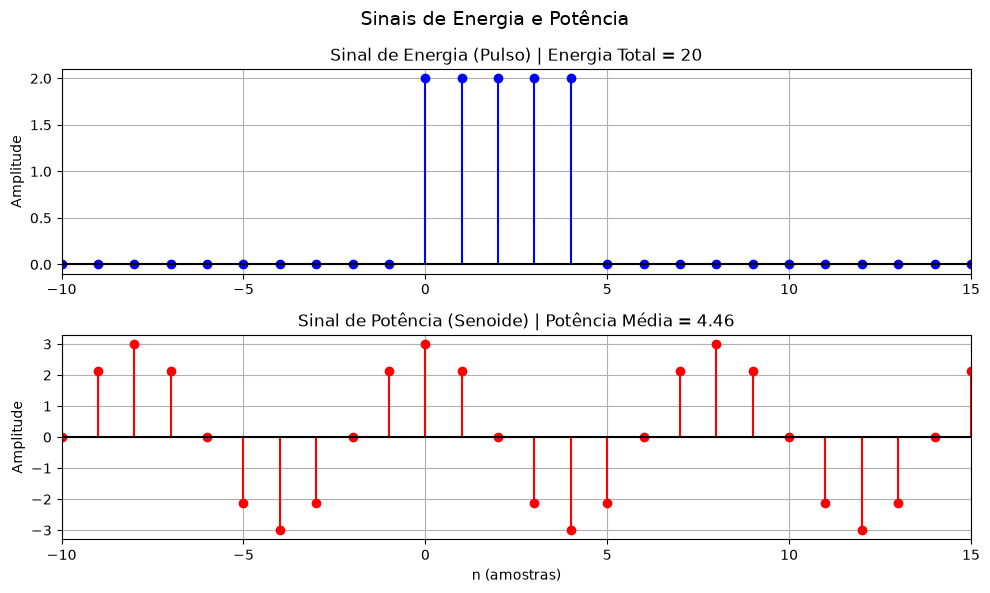

In [8]:
# intervalo de simulação
N_lim = 50
n = np.arange(-N_lim, N_lim + 1)

# sinal de energia
x_energia = np.where((n >= 0) & (n <= 4), 2, 0)

# sinal de potência
x_potencia = 3 * np.cos((np.pi / 4) * n)


# soma dos quadrados das amplitudes
energia_xE = np.sum(np.abs(x_energia)**2)
energia_xP = np.sum(np.abs(x_potencia)**2)

# energia dividida pelo número total de amostras do intervalo (2N + 1)
amostras_totais = 2 * N_lim + 1
potencia_xE = energia_xE / amostras_totais
potencia_xP = energia_xP / amostras_totais


print(f"Sinal de Energia (Pulso): E = {energia_xE:.2f} | P = {potencia_xE:.4f}")
print(f"Sinal de Potência (Senoide): E = {energia_xP:.2f} | P = {potencia_xP:.4f}")


fig, axes = plt.subplots(2, 1, figsize=(10, 6))
fig.suptitle('Sinais de Energia e Potência', fontsize=14)

axes[0].stem(n, x_energia, linefmt='b-', markerfmt='bo', basefmt='k-')
axes[0].set_title(f'Sinal de Energia (Pulso) | Energia Total = {energia_xE}')
axes[0].set_xlim(-10, 15)
axes[0].set_ylabel('Amplitude')
axes[0].grid(True)

axes[1].stem(n, x_potencia, linefmt='r-', markerfmt='ro', basefmt='k-')
axes[1].set_title(f'Sinal de Potência (Senoide) | Potência Média = {potencia_xP:.2f}')
axes[1].set_xlim(-10, 15)
axes[1].set_ylabel('Amplitude')
axes[1].set_xlabel('n (amostras)')
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Tópico 7 - Sistemas Discretos

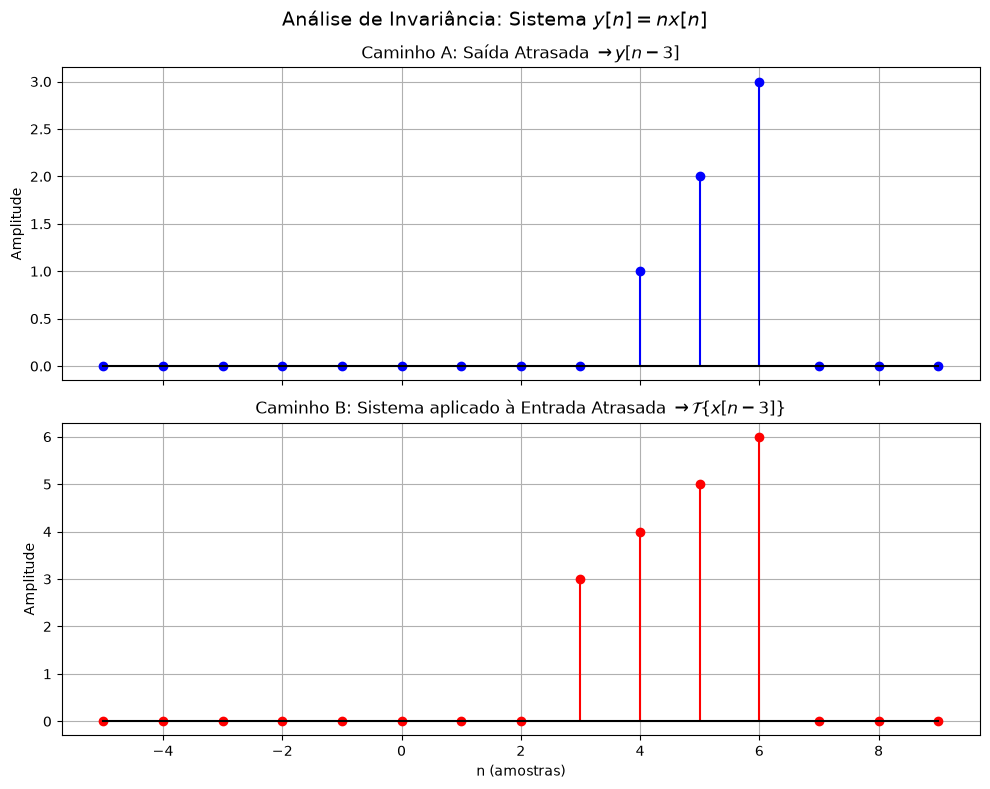

In [9]:
# vetor de tempo
n = np.arange(-5, 10)

# y[n] = n * x[n]
def sistema_E(x, n_vetor):
    return n_vetor * x

# sinal de entrada
x_original = np.where((n >= 0) & (n <= 3), 1, 0)

y_original = sistema_E(x_original, n)
y_atrasado_pos_processamento = np.roll(y_original, 3)
y_atrasado_pos_processamento[:3] = 0

x_atrasado = np.where((n >= 3) & (n <= 6), 1, 0)
y_processado_pos_atraso = sistema_E(x_atrasado, n)

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
fig.suptitle('Análise de Invariância: Sistema $y[n] = n x[n]$', fontsize=14)

axes[0].stem(n, y_atrasado_pos_processamento, linefmt='b-', markerfmt='bo', basefmt='k-')
axes[0].set_title(r'Caminho A: Saída Atrasada $\rightarrow y[n-3]$')
axes[0].grid(True)
axes[0].set_ylabel('Amplitude')

axes[1].stem(n, y_processado_pos_atraso, linefmt='r-', markerfmt='ro', basefmt='k-')
axes[1].set_title(r'Caminho B: Sistema aplicado à Entrada Atrasada $\rightarrow \mathcal{T}\{x[n-3]\}$')
axes[1].grid(True)
axes[1].set_ylabel('Amplitude')
axes[1].set_xlabel('n (amostras)')

plt.tight_layout()
plt.show()

## Tópico 8 - Sistemas LTI

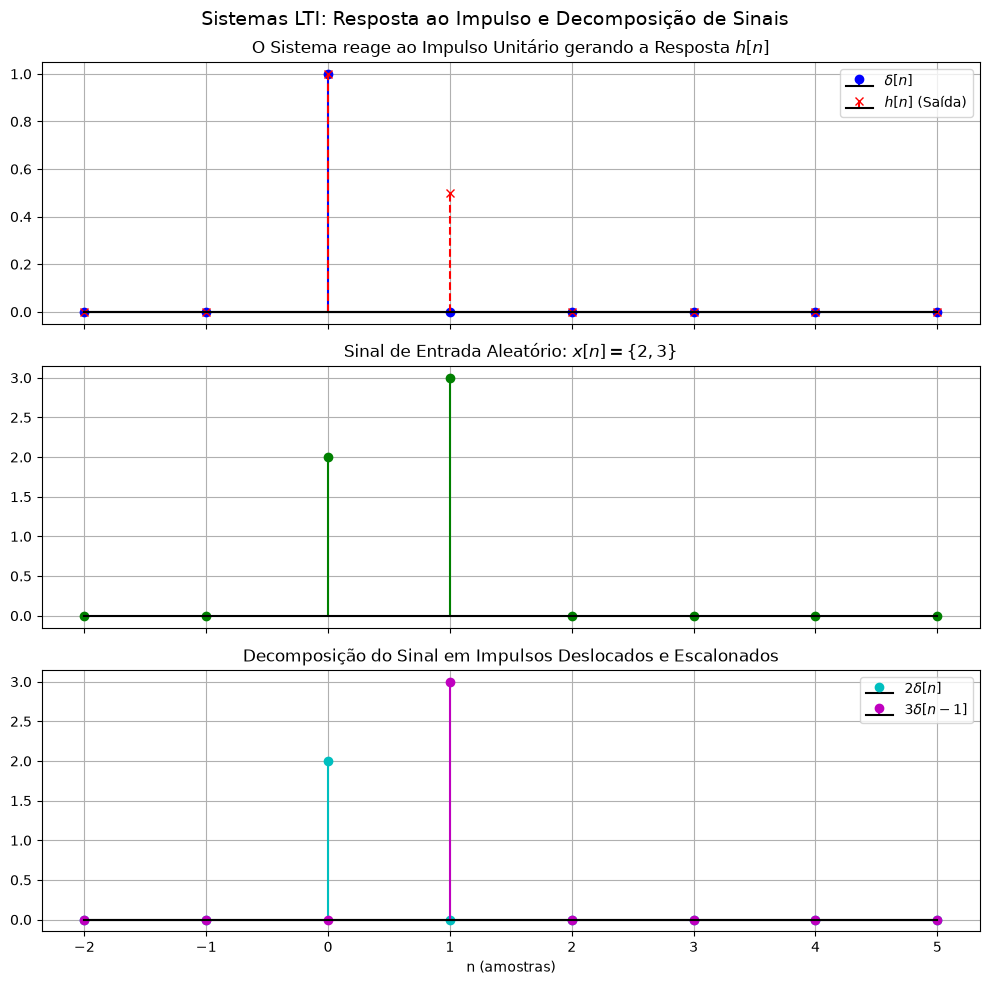

In [10]:
# vetor de tempo n
n = np.arange(-2, 6)

# sistema y[n] = x[n] + 0.5*x[n-1]
def sistema_LTI(x_entrada):
    y = np.zeros_like(x_entrada, dtype=float)
    for i in range(len(x_entrada)):
        # Condição para evitar índice negativo no array
        x_passado = x_entrada[i-1] if i > 0 else 0
        y[i] = x_entrada[i] + 0.5 * x_passado
    return y

# resposta ao impulso h[n]
impulso_unitario = np.where(n == 0, 1, 0)
h_n = sistema_LTI(impulso_unitario)

# decomposição de um sinal
x_n = np.where(n == 0, 2, np.where(n == 1, 3, 0))

impulso_1 = np.where(n == 0, 2, 0)
impulso_2 = np.where(n == 1, 3, 0)


fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)
fig.suptitle('Sistemas LTI: Resposta ao Impulso e Decomposição de Sinais', fontsize=14)

axes[0].stem(n, impulso_unitario, linefmt='b-', markerfmt='bo', basefmt='k-', label=r'$\delta[n]$')
axes[0].stem(n, h_n, linefmt='r--', markerfmt='rx', basefmt='k-', label=r'$h[n]$ (Saída)')
axes[0].set_title(r'O Sistema reage ao Impulso Unitário gerando a Resposta $h[n]$')
axes[0].legend()
axes[0].grid(True)

axes[1].stem(n, x_n, linefmt='g-', markerfmt='go', basefmt='k-')
axes[1].set_title(r'Sinal de Entrada Aleatório: $x[n] = \{2, 3\}$')
axes[1].grid(True)

axes[2].stem(n, impulso_1, linefmt='c-', markerfmt='co', basefmt='k-', label=r'$2\delta[n]$')
axes[2].stem(n, impulso_2, linefmt='m-', markerfmt='mo', basefmt='k-', label=r'$3\delta[n-1]$')
axes[2].set_title(r'Decomposição do Sinal em Impulsos Deslocados e Escalonados')
axes[2].set_xlabel('n (amostras)')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

## Tópico 9 - Convulação Discreta

Cálculo Computacional y[n]: [1 3 3 1]
Cálculo Modificado y_mod[n]: [ 1  1 -1 -1]


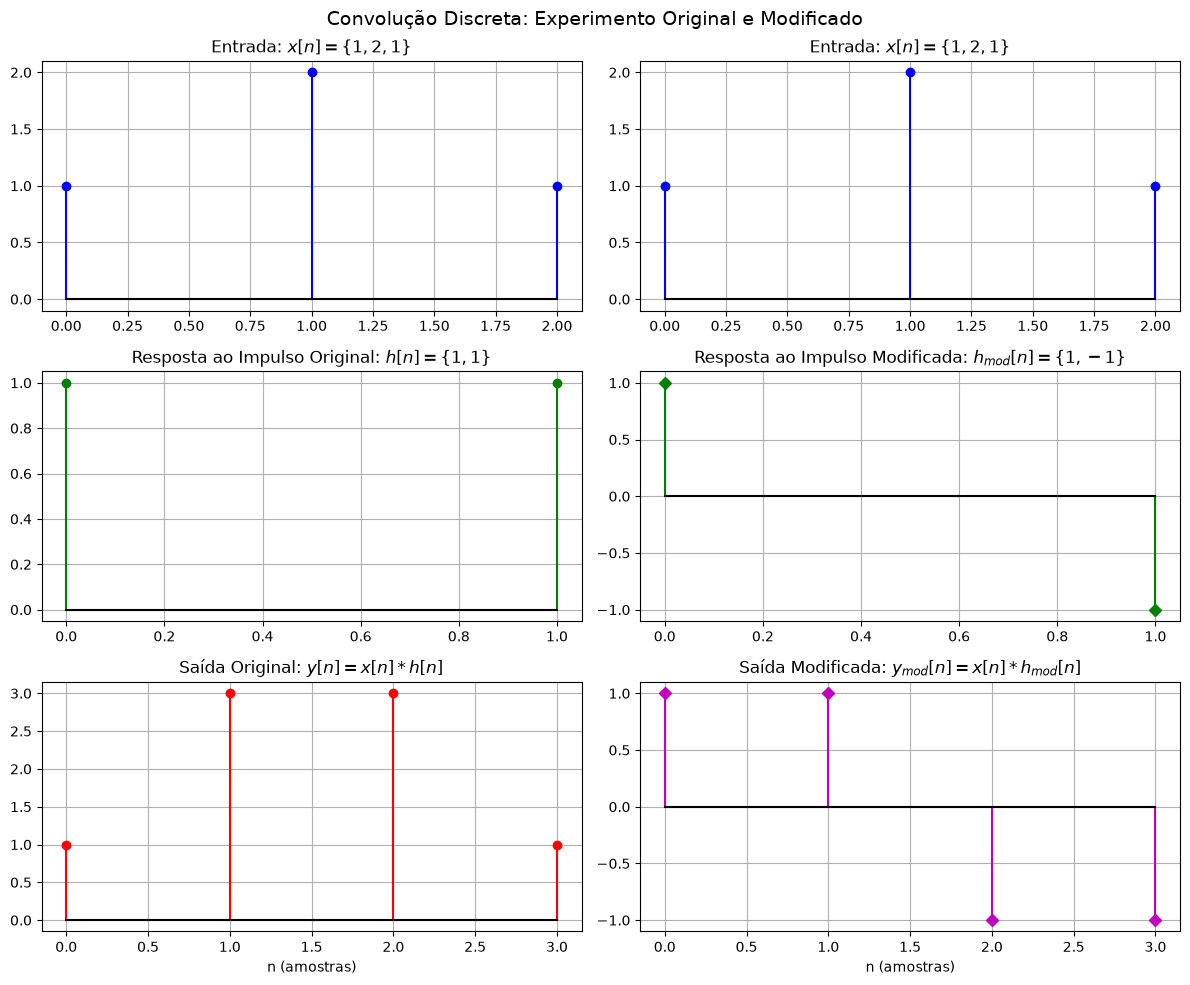

In [11]:
# sinais originais
x = np.array([1, 2, 1])
h = np.array([1, 1])

# sinal modificado
h_mod = np.array([1, -1])

# cálculo da convolução
y = np.convolve(x, h)
y_mod = np.convolve(x, h_mod)

# eixos de tempo
n_x = np.arange(len(x))
n_h = np.arange(len(h))
n_y = np.arange(len(y))

# verificação numérica
print(f"Cálculo Computacional y[n]: {y}")
print(f"Cálculo Modificado y_mod[n]: {y_mod}")

# Plotagem dos resultados
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
fig.suptitle('Convolução Discreta: Experimento Original e Modificado', fontsize=14)

# original
axes[0, 0].stem(n_x, x, linefmt='b-', markerfmt='bo', basefmt='k-')
axes[0, 0].set_title(r'Entrada: $x[n] = \{1, 2, 1\}$')
axes[0, 0].grid(True)

axes[1, 0].stem(n_h, h, linefmt='g-', markerfmt='go', basefmt='k-')
axes[1, 0].set_title(r'Resposta ao Impulso Original: $h[n] = \{1, 1\}$')
axes[1, 0].grid(True)

axes[2, 0].stem(n_y, y, linefmt='r-', markerfmt='ro', basefmt='k-')
axes[2, 0].set_title(r'Saída Original: $y[n] = x[n] * h[n]$')
axes[2, 0].set_xlabel('n (amostras)')
axes[2, 0].grid(True)

# modificado
axes[0, 1].stem(n_x, x, linefmt='b-', markerfmt='bo', basefmt='k-')
axes[0, 1].set_title(r'Entrada: $x[n] = \{1, 2, 1\}$')
axes[0, 1].grid(True)

axes[1, 1].stem(n_h, h_mod, linefmt='g-', markerfmt='gD', basefmt='k-')
axes[1, 1].set_title(r'Resposta ao Impulso Modificada: $h_{mod}[n] = \{1, -1\}$')
axes[1, 1].grid(True)

axes[2, 1].stem(n_y, y_mod, linefmt='m-', markerfmt='mD', basefmt='k-')
axes[2, 1].set_title(r'Saída Modificada: $y_{mod}[n] = x[n] * h_{mod}[n]$')
axes[2, 1].set_xlabel('n (amostras)')
axes[2, 1].grid(True)

plt.tight_layout()
plt.show()

## Tópico 10 - Convolução com Filtragem

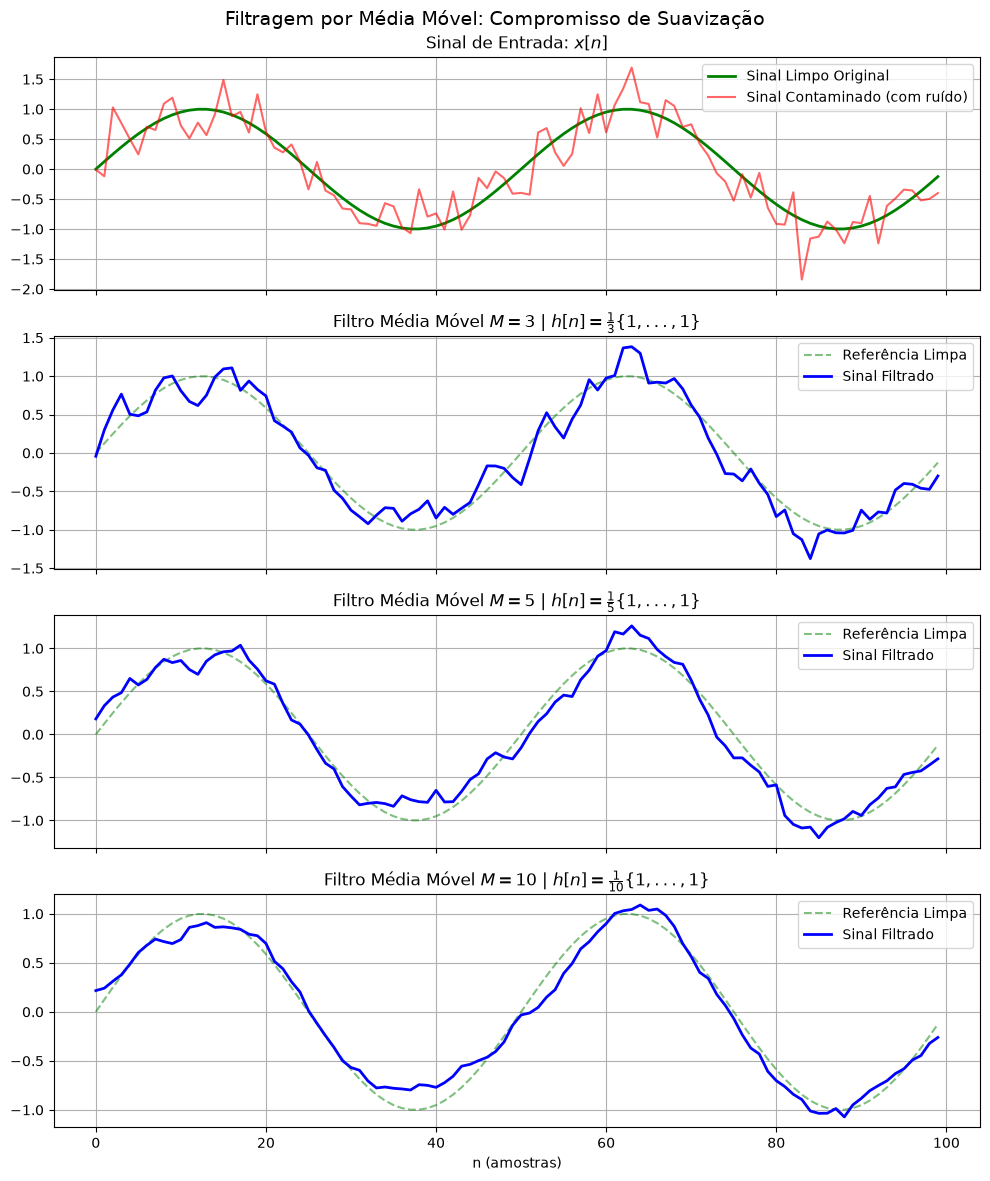

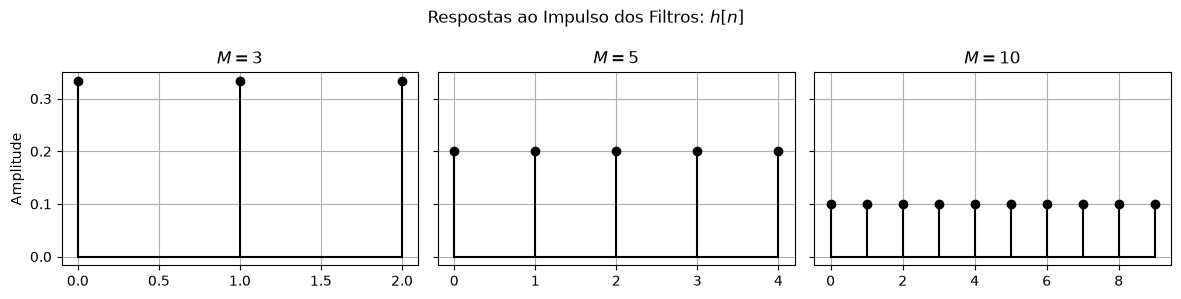

In [12]:
# geração do sinal original e do ruído
n = np.arange(0, 100)
sinal_limpo = np.sin(2 * np.pi * 0.02 * n)
ruido = 0.3 * np.random.randn(len(n))
sinal_contaminado = sinal_limpo + ruido

# valores de M
M_valores = [3, 5, 10]

fig, axes = plt.subplots(4, 1, figsize=(10, 12), sharex=True)
fig.suptitle('Filtragem por Média Móvel: Compromisso de Suavização', fontsize=14)

axes[0].plot(n, sinal_limpo, 'g-', linewidth=2, label='Sinal Limpo Original')
axes[0].plot(n, sinal_contaminado, 'r-', alpha=0.6, label='Sinal Contaminado (com ruído)')
axes[0].set_title(r'Sinal de Entrada: $x[n]$')
axes[0].legend()
axes[0].grid(True)

for i, M in enumerate(M_valores):
    h_M = np.ones(M) / M

    # filtragem através da convolução
    sinal_filtrado = np.convolve(sinal_contaminado, h_M, mode='same')

    ax = axes[i+1]
    ax.plot(n, sinal_limpo, 'g--', alpha=0.5, label='Referência Limpa')
    ax.plot(n, sinal_filtrado, 'b-', linewidth=2, label=f'Sinal Filtrado')

    titulo = r'Filtro Média Móvel $M=' + str(M) + r'$ | $h[n] = \frac{1}{' + str(M) + r'} \{1, ..., 1\}$'
    ax.set_title(titulo)

    ax.legend(loc='upper right')
    ax.grid(True)

axes[-1].set_xlabel('n (amostras)')
plt.tight_layout()
plt.show()

fig2, axes2 = plt.subplots(1, 3, figsize=(12, 3), sharey=True)
fig2.suptitle('Respostas ao Impulso dos Filtros: $h[n]$', fontsize=12)

for i, M in enumerate(M_valores):
    h_M = np.ones(M) / M
    n_h = np.arange(M)
    axes2[i].stem(n_h, h_M, linefmt='k-', markerfmt='ko', basefmt='k-')
    axes2[i].set_title(r'$M=' + str(M) + r'$')
    axes2[i].grid(True)

axes2[0].set_ylabel('Amplitude')
plt.tight_layout()
plt.show()